In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/guacnn640/data/valid/scorch/scorch0044ba_jpg.rf.47d704c9d4e550bbbd5a8dc545ef59c5_dup345.jpg
/kaggle/input/guacnn640/data/valid/scorch/scorch020_jpg.rf.c8e4d686da1cc3e74d8254f1ca040c4f_dup71.jpg
/kaggle/input/guacnn640/data/valid/scorch/scorch0040ba_jpg.rf.e529dd35b94f963475e21081c7a1528c_dup267.jpg
/kaggle/input/guacnn640/data/valid/scorch/scorch026_jpg.rf.a4f6b8ebcca45780317d0098711c348b_dup312.jpg
/kaggle/input/guacnn640/data/valid/scorch/scorch0003ba_jpg.rf.89f1c2d73a9fc9150e6bd0a101f4cc2d.jpg
/kaggle/input/guacnn640/data/valid/scorch/scorch0002ba_jpg.rf.18c457abca3a4d43bccf29f3148b0abe_dup702.jpg
/kaggle/input/guacnn640/data/valid/scorch/scorch0038ba_jpg.rf.c8ad1d7686f08cf43da493d0d85be481.jpg
/kaggle/input/guacnn640/data/valid/scorch/scorch0012ff_jpg.rf.71b8a421eb168b8630afbd2297e01030.jpg
/kaggle/input/guacnn640/data/valid/scorch/scorch0037sa_jpg.rf.4e34dc01f5cbd3e18fd83f25ea0c4d4f_dup41.jpg
/kaggle/input/guacnn640/data/valid/scorch/scorch0010ba_jpg.rf.692ada18879ec

In [3]:
import torch
torch.cuda.is_available()

True

In [7]:
# ===============================
# 2️⃣ Kaggle API Setup (Kaggle Only)
# ===============================
import os

# Check if the kaggle.json file exists
if os.path.exists('/kaggle/input/kaggle-json/kaggle.json'):
    os.environ['KAGGLE_CONFIG_DIR'] = '/kaggle/working'
    !mkdir -p ~/.kaggle
    !cp /kaggle/input/kaggle-json/kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print("✅ Kaggle API configured successfully!")
else:
    print("❌ kaggle.json not found! Please upload it using 'Add data' → 'Upload'.")


❌ kaggle.json not found! Please upload it using 'Add data' → 'Upload'.


In [8]:
import os

if os.path.exists('/kaggle/input/kaggle-json/kaggle.json'):
    os.environ['KAGGLE_CONFIG_DIR'] = '/kaggle/working'
    !mkdir -p ~/.kaggle
    !cp /kaggle/input/kaggle-json/kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print("✅ Kaggle API configured successfully!")
else:
    print("❌ kaggle.json not found! Please upload it using 'Add data' → 'Upload'.")


❌ kaggle.json not found! Please upload it using 'Add data' → 'Upload'.


In [9]:
# ===============================================================
# ✅ STEP 1: Configure Kaggle API in Kaggle Notebook
# ===============================================================
import os

kaggle_json_path = '/kaggle/input/kaggle-json/kaggle.json'
local_kaggle_path = '/root/.kaggle/kaggle.json'

if os.path.exists(kaggle_json_path):
    print("✅ Found kaggle.json in input folder.")
    os.makedirs('/root/.kaggle', exist_ok=True)
    os.system(f'cp {kaggle_json_path} {local_kaggle_path}')
    os.chmod(local_kaggle_path, 0o600)
    print("✅ Kaggle API configured successfully!")
else:
    print("❌ kaggle.json not found!")
    print("""
    👉 To fix:
       1️⃣ Go to your Kaggle account → Settings → Create New API Token
       2️⃣ Upload the downloaded kaggle.json file:
           Right sidebar → 'Add Data' → 'Upload' → Select kaggle.json
       3️⃣ Re-run this cell
    """)

# ===============================================================
# ✅ STEP 2: Test Kaggle API connection
# ===============================================================
if os.path.exists(local_kaggle_path):
    print("\n🔍 Testing Kaggle API...")
    !kaggle datasets list -s guacnn640 | head -n 10
else:
    print("\n🚫 Kaggle.json not found, skipping test.")


❌ kaggle.json not found!

    👉 To fix:
       1️⃣ Go to your Kaggle account → Settings → Create New API Token
       2️⃣ Upload the downloaded kaggle.json file:
           Right sidebar → 'Add Data' → 'Upload' → Select kaggle.json
       3️⃣ Re-run this cell
    

🚫 Kaggle.json not found, skipping test.


✅ Dataset directories:
Train: /kaggle/input/guacnn640/data/train
Valid: /kaggle/input/guacnn640/data/valid
Test : /kaggle/input/guacnn640/data/test
Found 9000 images belonging to 9 classes.
Found 1125 images belonging to 9 classes.
Found 1125 images belonging to 9 classes.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 640, 640, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 640, 640, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 320, 320, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 320, 320, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 160, 160, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 160, 160, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 80, 80, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 80, 80, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 40, 40, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,473 (1.61 MB)

 Trainable params: 422,473 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 0s 755ms/step - accuracy: 0.2499 - loss: 1.9178
Epoch 1: val_loss improved from inf to 1.19194, saving model to /kaggle/working/best_cnn_model.h5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 883s 781ms/step - accuracy: 0.2500 - loss: 1.9177 - val_accuracy: 0.5982 - val_loss: 1.1919
Epoch 2/50
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 0s 727ms/step - accuracy: 0.5414 - loss: 1.3204
Epoch 2: val_loss improved from 1.19194 to 0.88834, saving model to /kaggle/working/best_cnn_model.h5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 834s 742ms/step - accuracy: 0.5414 - loss: 1.3203 - val_accuracy: 0.6702 - val_loss: 0.8883
Epoch 3/50
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.6289 - loss: 1.0513
Epoch 3: val_loss improved from 0.88834 to 0.71459, saving model to /kaggle/working/best_cnn_model.h5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 828s 736ms/step - accuracy: 0.6290 - loss: 1.0512 - val_accuracy: 0.7769 - val_loss: 0.7146
Epoch 4/50
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 0s 731ms/step - a

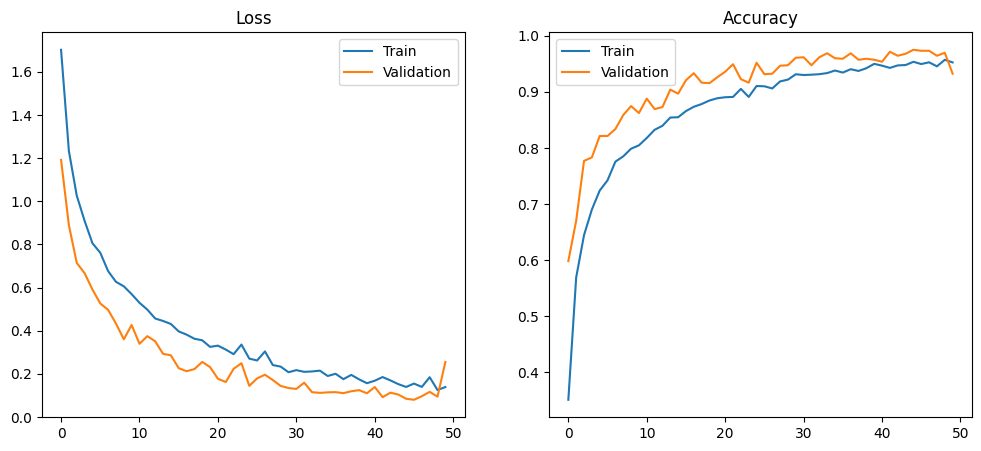

141/141 ━━━━━━━━━━━━━━━━━━━━ 26s 185ms/step - accuracy: 0.9486 - loss: 0.1783
✅ Test Accuracy: 0.9387
✅ Test Loss: 0.2210
💾 Final model saved to: /kaggle/working/cnn_image_classifier_final.h5


In [10]:
# ===============================================================
# ✅ STEP 1: Import Libraries
# ===============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, Input
from tensorflow.keras.callbacks import ModelCheckpoint

# ===============================================================
# ✅ STEP 2: Set Paths
# ===============================================================
# After attaching the dataset, it will be stored here:
base_dir = '/kaggle/input/guacnn640/data'
train_dir = os.path.join(base_dir, 'train')
valid_dir = os.path.join(base_dir, 'valid')
test_dir = os.path.join(base_dir, 'test')
save_dir = '/kaggle/working'

print("✅ Dataset directories:")
print(f"Train: {train_dir}")
print(f"Valid: {valid_dir}")
print(f"Test : {test_dir}")

# ===============================================================
# ✅ STEP 3: Parameters
# ===============================================================
img_height, img_width = 640, 640
batch_size = 8
epochs = 50

# ===============================================================
# ✅ STEP 4: Data Generators
# ===============================================================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    valid_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# ===============================================================
# ✅ STEP 5: Build CNN Model
# ===============================================================
inp = Input(shape=(img_height, img_width, 3))
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inp)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(train_gen.num_classes, activation='softmax')(x)

model = models.Model(inputs=inp, outputs=out)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# ===============================================================
# ✅ STEP 6: Model Checkpoint
# ===============================================================
checkpoint = ModelCheckpoint(
    os.path.join(save_dir, 'best_cnn_model.h5'),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# ===============================================================
# ✅ STEP 7: Train Model
# ===============================================================
history = model.fit(
    train_gen,
    epochs=epochs,
    validation_data=val_gen,
    callbacks=[checkpoint]
)

# ===============================================================
# ✅ STEP 8: Plot Metrics
# ===============================================================
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(history.history['loss'], label='Train')
ax[0].plot(history.history['val_loss'], label='Validation')
ax[0].set_title('Loss')
ax[0].legend()
ax[1].plot(history.history['accuracy'], label='Train')
ax[1].plot(history.history['val_accuracy'], label='Validation')
ax[1].set_title('Accuracy')
ax[1].legend()
plt.show()

# ===============================================================
# ✅ STEP 9: Evaluate Model
# ===============================================================
test_loss, test_acc = model.evaluate(test_gen)
print(f"✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Test Loss: {test_loss:.4f}")

# ===============================================================
# ✅ STEP 🔟: Save Final Model
# ===============================================================
final_model_path = os.path.join(save_dir, 'cnn_image_classifier_final.h5')
model.save(final_model_path)
print(f"💾 Final model saved to: {final_model_path}")


In [14]:
from tensorflow.keras.models import load_model

# Choose which one you want to load
model_path = '/kaggle/working/cnn_image_classifier_final.h5'  # or '/kaggle/working/best_cnn_model.h5'

# Load the model
model = load_model(model_path)

# Confirm it loaded successfully
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 640, 640, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 640, 640, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 320, 320, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 320, 320, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 160, 160, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 160, 160, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 80, 80, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 80, 80, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 40, 40, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,475 (1.61 MB)

 Trainable params: 422,473 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [15]:
test_loss, test_acc = model.evaluate(test_gen)
print(f"✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Test Loss: {test_loss:.4f}")


141/141 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - accuracy: 0.9486 - loss: 0.1783
✅ Test Accuracy: 0.9387
✅ Test Loss: 0.2210


In [16]:
# Print final training & validation metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"🏋️‍♂️ Final Training Accuracy: {final_train_acc:.4f}")
print(f"🧪 Final Validation Accuracy: {final_val_acc:.4f}")
print(f"📉 Final Training Loss: {final_train_loss:.4f}")
print(f"📊 Final Validation Loss: {final_val_loss:.4f}")


🏋️‍♂️ Final Training Accuracy: 0.9526
🧪 Final Validation Accuracy: 0.9324
📉 Final Training Loss: 0.1392
📊 Final Validation Loss: 0.2553


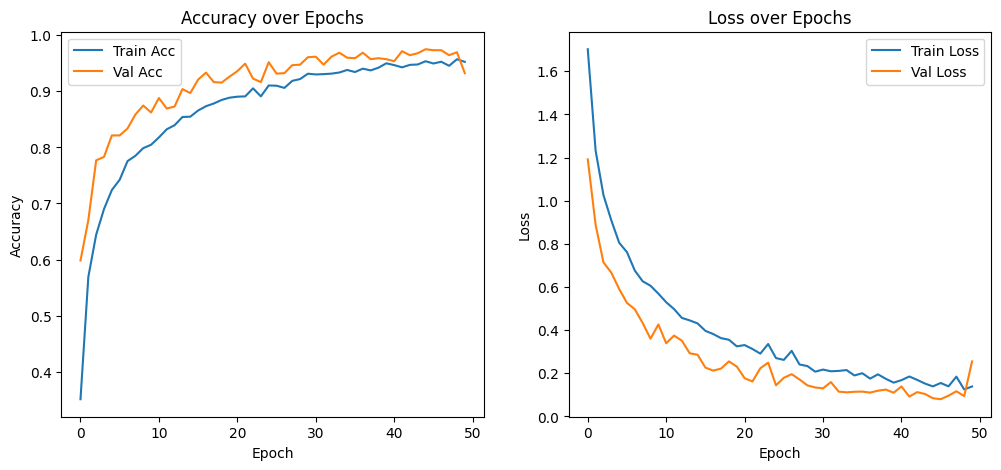

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


141/141 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step


<Figure size 1000x1000 with 0 Axes>

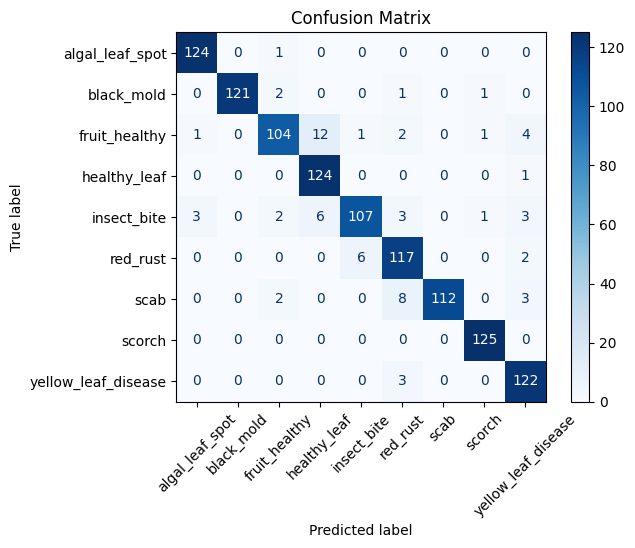

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict all test data
Y_pred = model.predict(test_gen)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_gen.classes

# Class labels
class_names = list(test_gen.class_indices.keys())

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(10,10))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


In [ ]:
print("RRKK")